## MetENP

MetENP is a R package that enables detection of significant metabolites from metabolite information 
(names or names and concentration along with metadata information) and provides

1. Enrichment score of metabolite class,
2. Maps to pathway of the species of choice,
3. Calculate enrichment score of pathways,
4. Plots the pathways and shows the metabolite increase or decrease
5. Gets gene info, reaction info, enzyme info

For more info, check out the vignette.

In [1]:
if (!requireNamespace("KEGGREST", quietly = TRUE))
    BiocManager::install("KEGGREST", update = TRUE, ask = FALSE)

if (!requireNamespace("KEGGgraph", quietly = TRUE))
    BiocManager::install("KEGGgraph", update = TRUE, ask = FALSE)

if (!requireNamespace("pathview", quietly = TRUE))
    BiocManager::install("pathview", update = TRUE, ask = FALSE)

#if (!requireNamespace("KEGG.db", quietly = TRUE))
#    BiocManager::install("KEGG.db", update = TRUE, ask = FALSE)

#if (!requireNamespace("MetENP", quietly = TRUE))
#    devtools::install("..", upgrade = "never")



##############################################################################
Pathview is an open source software package distributed under GNU General
Public License version 3 (GPLv3). Details of GPLv3 is available at
http://www.gnu.org/licenses/gpl-3.0.html. Particullary, users are required to
formally cite the original Pathview paper (not just mention it) in publications
or products. For details, do citation("pathview") within R.

The pathview downloads and uses KEGG data. Non-academic uses may require a KEGG
license agreement (details at http://www.kegg.jp/kegg/legal.html).
##############################################################################



In [2]:
USER_HOME=Sys.getenv("HOME");
USER_PWD=Sys.getenv("PWD");
#.libPaths( c( .libPaths(), paste0(USER_HOME, "/.local/R") ))
.libPaths( c( .libPaths(), paste0(USER_PWD, "/../../R") )); # suitable path to where MetENP R package is installed
#.libPaths( c( .libPaths(), paste0("../../R") )); # suitable path to where MetENP R package is installed

library(MetENP)

#### If you do not wish to install, alternatively, download from github(https://github.com/metabolomicsworkbench/MetENP) and load libraries and functions
#### Complete information for this study is at Metabolomics Workbench: https://www.metabolomicsworkbench.org/data/DRCCMetadata.php?Mode=Study&StudyID=ST000915&StudyType=MS&ResultType=1

In [3]:
data = getmwstudies('ST000915', 'data')
head(data)

analysis_id <NA>     <NA>     <NA>     <NA>     <NA>    
1 AN001485    AN001485 AN001485 AN001485 AN001485 AN001485
2 AN001485    AN001485 AN001485 AN001485 AN001485 AN001485
3 AN001485    AN001485 AN001485 AN001485 AN001485 AN001485
4 AN001485    AN001485 AN001485 AN001485 AN001485 AN001485
5 AN001485    AN001485 AN001485 AN001485 AN001485 AN001485
6 AN001485    AN001485 AN001485 AN001485 AN001485 AN001485
  analysis_summary               <NA>                          
1 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids
2 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids
3 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids
4 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids
5 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids
6 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids
  <NA>                           <NA>                          
1 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids
2 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids
3 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids
4 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids
5 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids
6 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids
  <NA>                           <NA>                           metabolite_name
1 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids 10 HDoHE       
2 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids 10 HDoHE       
3 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids 10 HDoHE       
4 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids 10 HDoHE       
5 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids 10 HDoHE       
6 Core G Fatty acids/Eicosanoids Core G Fatty acids/Eicosanoids 10 HDoHE       
  <NA>          <NA>      <NA>     <NA>     <NA>    metabolite_id <NA>    
1 11,12-diHETrE 11,12-EET 11b PGE2 11 HDoHE 11-HEPE ME230937      ME230961
2 11,12-diHETrE 11,12-EET 11b PGE2 11 HDoHE 11-HEPE ME230937      ME230961
3 11,12-diHETrE 11,12-EET 11b PGE2 11 HDoHE 11-HEPE ME230937      ME230961
4 11,12-diHETrE 11,12-EET 11b PGE2 11 HDoHE 11-HEPE ME230937      ME230961
5 11,12-diHETrE 11,12-EET 11b PGE2 11 HDoHE 11-HEPE ME230937      ME230961
6 11,12-diHETrE 11,12-EET 11b PGE2 11 HDoHE 11-HEPE ME230937      ME230961
  <NA>     <NA>     <NA>     <NA>     refmet_name <NA>          <NA>        
1 ME230954 ME230914 ME230941 ME230917 10-HDoHE    11,12-DiHETrE 11,12-EpETrE
2 ME230954 ME230914 ME230941 ME230917 10-HDoHE    11,12-DiHETrE 11,12-EpETrE
3 ME230954 ME230914 ME230941 ME230917 10-HDoHE    11,12-DiHETrE 11,12-EpETrE
4 ME230954 ME230914 ME230941 ME230917 10-HDoHE    11,12-DiHETrE 11,12-EpETrE
5 ME230954 ME230914 ME230941 ME230917 10-HDoHE    11,12-DiHETrE 11,12-EpETrE
6 ME230954 ME230914 ME230941 ME230917 10-HDoHE    11,12-DiHETrE 11,12-EpETrE
  <NA>        <NA>     <NA>    NASH001 NASH002 NASH003 NASH004 NASH005 ⋯
1 11beta-PGE2 11-HDoHE 11-HEPE 0.00419 0.01396 0.00285 0.00705 0.00020 ⋯
2 11beta-PGE2 11-HDoHE 11-HEPE 0.01346 1.84739 0.63897 1.87466 0.21119 ⋯
3 11beta-PGE2 11-HDoHE 11-HEPE 0.20666 0.12915 0.18170 0.11368 0.06081 ⋯
4 11beta-PGE2 11-HDoHE 11-HEPE 0.00048 0.00128 NA      NA      NA      ⋯
5 11beta-PGE2 11-HDoHE 11-HEPE 0.00617 0.03174 0.00958 0.00593 0.00271 ⋯
6 11beta-PGE2 11-HDoHE 11-HEPE 0.00642 NA      0.01625 0.02049 0.00115 ⋯
  NASH082 NASH083 NASH084 NASH085 NASH086 NASH087 NASH088 NASH089 NASH090
1 0.00073 0.00641 0.00667 0.00143 0.02844 0.02243 0.00915 0.00366 0.00208
2 0.06045 0.03386 0.01953 0.02720 0.02104 0.06057 0.03444 0.01259 0.02891
3 0.97974 0.66245 0.19845 0.30318 0.37735 0.67719 0.64060 0.39347 0.22317
4 0.00098 0.00206 0.00076 0.00213 0.00093 0.02040 0.02086 0.00070 0.00136
5 0.01842 0.01902 0.01049 0.00151 0.02371 0.03326 0.00267 0.00232 NA     
6 0.02481 0.00969 0.00109 NA      0.02083 0.00539 0.00666 0.00745 0.01074
  NASH091
1 0.00144
2 0.05983
3 0.38579


In [4]:
metadata = getmwstudies('ST000915', 'factors')
head(metadata)

,study_id,local_sample_id,sample_source,factors,mb_sample_id,raw_data,Diagnosis
,<named list>,<named list>,<named list>,<named list>,<named list>,<named list>,<chr>
1,ST000915,NASH005,Liver,Diagnosi....,SA053807,,Cirrhosis
2,ST000915,NASH007,Liver,Diagnosi....,SA053815,,Cirrhosis
3,ST000915,NASH009,Liver,Diagnosi....,SA053817,,Cirrhosis
4,ST000915,NASH013,Liver,Diagnosi....,SA053813,,Cirrhosis
5,ST000915,NASH016,Liver,Diagnosi....,SA053812,,Cirrhosis
6,ST000915,NASH022,Liver,Diagnosi....,SA053816,,Cirrhosis


Find the factors you would want to compare
Multiple factors (independent variables) are formatted in multiple columns but you can get information on all the factors by "factors" column, such as 'TreatmentGroup:Prednisolone', this indicates column name 'TreatmentGroup' with factor Prednisolone. For t-test use the factors in the same column. For comparing multipe independent variables use anova by anova_ana function.


### Associate metabolomics data to the refmet class


In [5]:

refmet_class= convert_refmet(data)
head(refmet_class)

,metabolite_name,analysis_id,analysis_summary,metabolite_id,refmet_name,NASH001,NASH002,NASH003,NASH004,NASH005,⋯,NASH087,NASH088,NASH089,NASH090,NASH091,formula,super_class,main_class,sub_class,refmet_id
,<chr>,<named list>,<named list>,<named list>,<named list>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,"1,2-DG(30:0)",AN001488,Core E N....,ME231190,"1,2-DG 30:0",2.7,NA,NA,NA,NA,⋯,68.2,87.9,33.1,45.7,9.2,C33H64O5,Glycerolipids,Diradylglycerols,DAG,RM0035472
2,"1,2-DG(30:1)",AN001488,Core E N....,ME231189,"1,2-DG 30:1",1.8,NA,NA,NA,NA,⋯,24.2,34.9,15.2,26.0,5.5,C33H62O5,Glycerolipids,Diradylglycerols,DAG,RM0030559
3,"1,2-DG(32:0)",AN001488,Core E N....,ME231196,"1,2-DG 32:0",12.2,7.1,2.2,2.0,1.4,⋯,221.6,300.8,115.0,200.2,29.4,C35H68O5,Glycerolipids,Diradylglycerols,DAG,RM0033817
4,"1,2-DG(32:1)",AN001488,Core E N....,ME231195,"1,2-DG 32:1",7.6,5.7,2.1,1.4,1.1,⋯,134.5,217.6,88.8,151.2,26.5,C35H66O5,Glycerolipids,Diradylglycerols,DAG,RM0033888
5,"1,2-DG(32:2)",AN001488,Core E N....,ME231194,"1,2-DG 32:2",2.0,1.9,NA,NA,NA,⋯,77.9,125.3,63.7,92.7,18.6,C35H64O5,Glycerolipids,Diradylglycerols,DAG,RM0033590
6,"1,2-DG(32:3)",AN001488,Core E N....,ME231193,"1,2-DG 32:3",NA,NA,NA,NA,NA,⋯,7.8,16.1,8.5,11.4,3.8,C35H62O5,Glycerolipids,Diradylglycerols,DAG,RM0030553


In [6]:
unique(metadata$factors)


[[1]]
[1] "Diagnosis:Cirrhosis"

[[2]]
[1] "Diagnosis:NASH"

[[3]]
[1] "Diagnosis:Normal"

[[4]]
[1] "Diagnosis:Steatosis"

In [7]:
### Find the analysis mode
unique(data$analysis_summary)

[[1]]
[1] "Core G Fatty acids/Eicosanoids"

[[2]]
[1] "Core J Sterols"

[[3]]
[1] "Core K Prenols/Cardiolipins"

[[4]]
[1] "Core E Neutral Lipids"

[[5]]
[1] "Core I Sphingolipids"

[[6]]
[1] "Core H Phospholipids"

### Find significant metabolites, run significance of all the analysis summary together. The analysis summary/modes you got in the previous section
There is a normalization step which takes into account missing values, and this can be achieved via three methods:

1) half_of_min: where the NAs are replaced by half of min values in the data

2) remove_NAs: where Cols with NAs values are removed

3) 50percent: where cols with more than 50% NAs values are removed, and then the remaining NA values are replaced with half_of_min

half_of_min is ideal when you wish to see which metabolites were present in either group. Very high fold change would mean it was present in either group. 

In [8]:
stats_metabolites = significant_met(metabolomics_data=refmet_class, met_col="metabolite_name",analysis_type=c('Core G Fatty acids/Eicosanoids', 'Core J Sterols', 'Core K Prenols/Cardiolipins', 'Core E Neutral Lipids', 'Core I Sphingolipids', 'Core H Phospholipids'), metadata=metadata, factor1='Cirrhosis', factor2=c('Normal'), factor_col='Diagnosis',sample_col='local_sample_id', p_adjust='fdr',normalization="50percent")

sig_metabolites = stats_metabolites[which(stats_metabolites[,"pval"] <= 0.05&abs(stats_metabolites[,"log2Fold_change"])>0.5),]


Warning message:
“ggrepel: 48 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


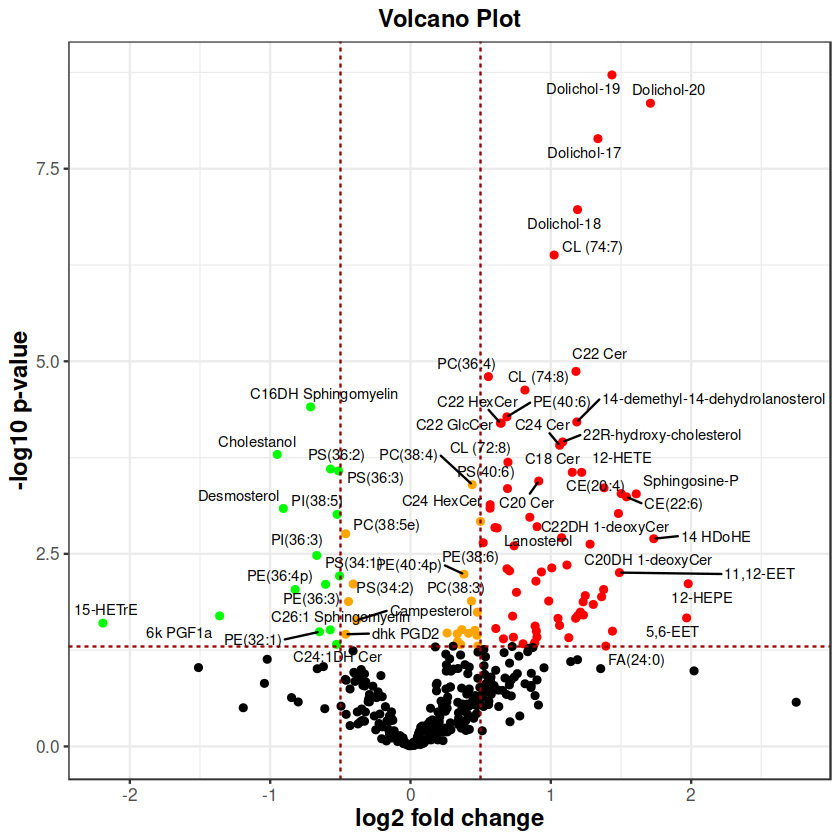

In [9]:
plot_volcano(stats_metabolites, thres_pval= 0.05,thres_log2foldchange = 0.5, TRUE)

### Map metabolite class of the significant metabolites utilzing refmet classification in Metabolomics Workbench
This function not only maps metabolite to metabolite class but also to external databases such as pubchem, inchi key, smiles and kegg

In this example, we will go forward with significant metabolite obtained by t-test/

In [10]:

sig_metabolites_kegg_id= map_keggid(sig_metabolites)
#sig_metabolites_kegg_id
save(sig_metabolites_kegg_id, refmet_class, file = "tmp/ST000915_sig_metabolites_kegg_id.RData");
head(sig_metabolites_kegg_id)

,refmet_name,Exact mass,KEGG ID,Metabolite,Cirrhosis_mean,Normal_mean,Fold_change,log2Fold_change,t_value,pval,padj,metabolite_id,super_class,main_class,sub_class,formula
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<named list>,<chr>,<chr>,<chr>,<chr>
1,1-DeoxyCer 18:0;O/16:0,523.5328,,C16DH 1-deoxyCer,0.05623685,0.12178748,2.165617,1.114778,-3.028001,0.0044113841,0.025170838,ME231305,Sphingolipids,Ceramides,1-deoxyCer,C34H69NO2
2,1-DeoxyCer 18:0;O/18:0,551.5641,,C18DH 1-deoxyCer,0.0906803,0.2566956,2.830776,1.501197,-3.826879,0.0005219699,0.005671347,ME231306,Sphingolipids,Ceramides,1-deoxyCer,C36H73NO2
3,1-DeoxyCer 18:0;O/20:0,579.5954,,C20DH 1-deoxyCer,0.0723488,0.1756429,2.427724,1.279604,-3.268230,0.0023663363,0.015081843,ME231307,Sphingolipids,Ceramides,1-deoxyCer,C38H77NO2
4,1-DeoxyCer 18:0;O/22:0,607.6267,,C22DH 1-deoxyCer,0.1513816,0.4227716,2.792754,1.481689,-3.604410,0.0009458421,0.007645557,ME231308,Sphingolipids,Ceramides,1-deoxyCer,C40H81NO2
5,1-DeoxyCer 18:0;O/24:0,635.6580,,C24DH 1-deoxyCer,0.1177141,0.3056195,2.596286,1.376449,-2.746084,0.0091800137,0.046866386,ME231310,Sphingolipids,Ceramides,1-deoxyCer,C42H85NO2
6,"1,2-DG 32:0",568.5067,C00641,"1,2-DG(32:0)",210.0625,479.9210,2.284658,1.191978,-2.410346,0.0200253888,0.106653539,ME231196,Glycerolipids,Diradylglycerols,DAG,C35H68O5


#### Check all your significant metabolites have not been assigned metabolite class

In [11]:
setdiff(sig_metabolites$refmet_name, sig_metabolites_kegg_id$refmet_name)

[1] "11,12-EpETrE" "14,15-EpETrE" "5,6-EpETrE"   ""             "PE P-36:4"

### Count metabolites in each of the metabolite class and plotting
You may choose from sub_class, main_class and super_class

In [12]:
count_changes = metcountplot(df_metclass=sig_metabolites_kegg_id, metclass='sub_class', plotting=TRUE, thres_logfC = 0.0, updown_fillcolor=c("red", "green"))
print(count_changes$sig_met_count)

            sub_class No.of_metabolites                 color
1                   -                 5 increased metabolites
2          1-deoxyCer                 5 increased metabolites
3                 BMP                 2 increased metabolites
4                 Cer                 1 increased metabolites
5        Chol. esters                 5 increased metabolites
6        Cholesterols                 1 increased metabolites
7                  CL                 3 increased metabolites
8                 DAG                 9 increased metabolites
9         Docosanoids                 3 increased metabolites
10          Dolichols                 4 increased metabolites
11             EpETrE                 1 increased metabolites
12               HEPE                 1 increased metabolites
13               HETE                 1 increased metabolites
14             HexCer                 5 increased metabolites
15                LPC                 1 increased metabolites
16      

Warning message:
“Use of `count_changes[[metclass]]` is discouraged.
ℹ Use `.data[[metclass]]` instead.”


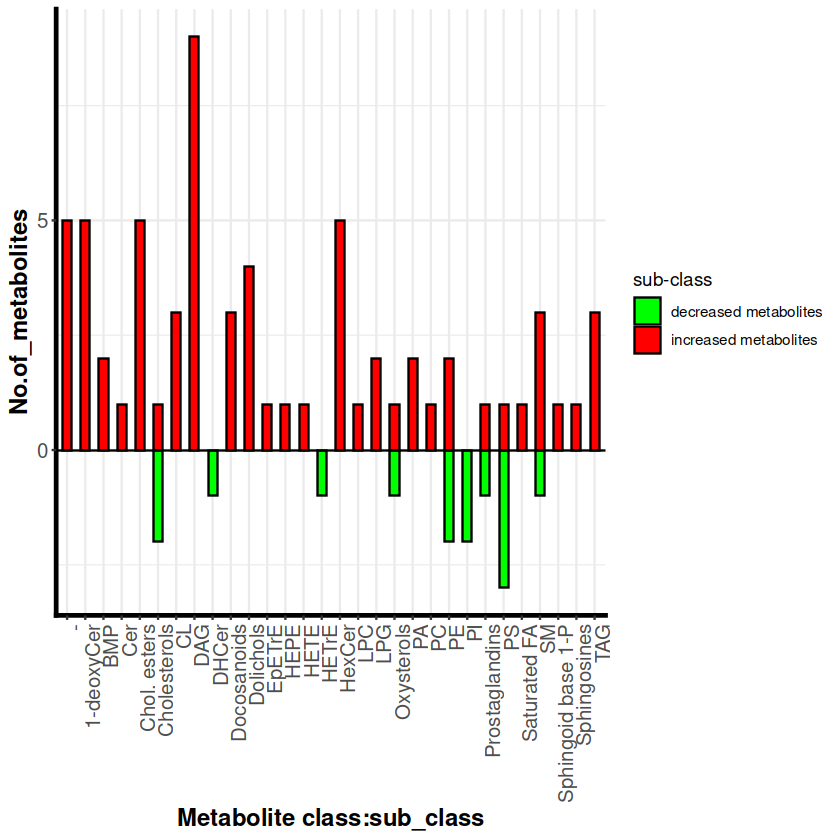

In [13]:
count_changes$plotimg

### Enrichment class score

Calculate the enrichment score of each metabolite class. Enrichment score is calculated through hypergeometric method. One can specify the no. of significant metabolites in a class while calculating the enrichment score. We advice to use the number of mtabolites in each class as 3 or more. But if someone just wants to know the enrichment score and rest of the information of all the metabolites, then they can choose the number as 1.

In [14]:
# pass debug = 0 below or comment some lines to suppress some print output
metenrichment = metclassenrichment(df_metclass=sig_metabolites_kegg_id,refmet_class, metclass="sub_class",enrich_stats="HG",no=1, debug = 0)
print(head(metenrichment))
#knitr::kable(head(metenrichment))
#metenrichment[metenrichment$main_class %in% c("Ceramides", "Sphingomyelins"), c("Metabolite", "pval", "super_class", "main_class", "sub_class", "HG p-value")]
#colnames(metenrichment)
#metenrichment$super_class
#metenrichment$main_class
#metenrichment$sub_class


             refmet_name Exact mass KEGG ID       Metabolite Cirrhosis_mean
1 1-DeoxyCer 18:0;O/16:0   523.5328         C16DH 1-deoxyCer     0.05623685
2 1-DeoxyCer 18:0;O/18:0   551.5641         C18DH 1-deoxyCer      0.0906803
3 1-DeoxyCer 18:0;O/20:0   579.5954         C20DH 1-deoxyCer      0.0723488
4 1-DeoxyCer 18:0;O/22:0   607.6267         C22DH 1-deoxyCer      0.1513816
5 1-DeoxyCer 18:0;O/24:0   635.6580         C24DH 1-deoxyCer      0.1177141
6            1,2-DG 32:0   568.5067  C00641     1,2-DG(32:0)       210.0625
  Normal_mean Fold_change log2Fold_change   t_value         pval        padj
1  0.12178748    2.165617        1.114778 -3.028001 0.0044113841 0.025170838
2   0.2566956    2.830776        1.501197 -3.826879 0.0005219699 0.005671347
3   0.1756429    2.427724        1.279604 -3.268230 0.0023663363 0.015081843
4   0.4227716    2.792754        1.481689 -3.604410 0.0009458421 0.007645557
5   0.3056195    2.596286        1.376449 -2.746084 0.0091800137 0.046866386
6    4

#### Plot the enrichment score via function plot_met_enrichment

Warning message:
“Use of `metclass_stats[[metclass]]` is discouraged.
ℹ Use `.data[[metclass]]` instead.”
Warning message:
“Use of `metclass_stats[[enrich_stats]]` is discouraged.
ℹ Use `.data[[enrich_stats]]` instead.”
Warning message:
“Use of `metclass_stats[[enrich_stats]]` is discouraged.
ℹ Use `.data[[enrich_stats]]` instead.”


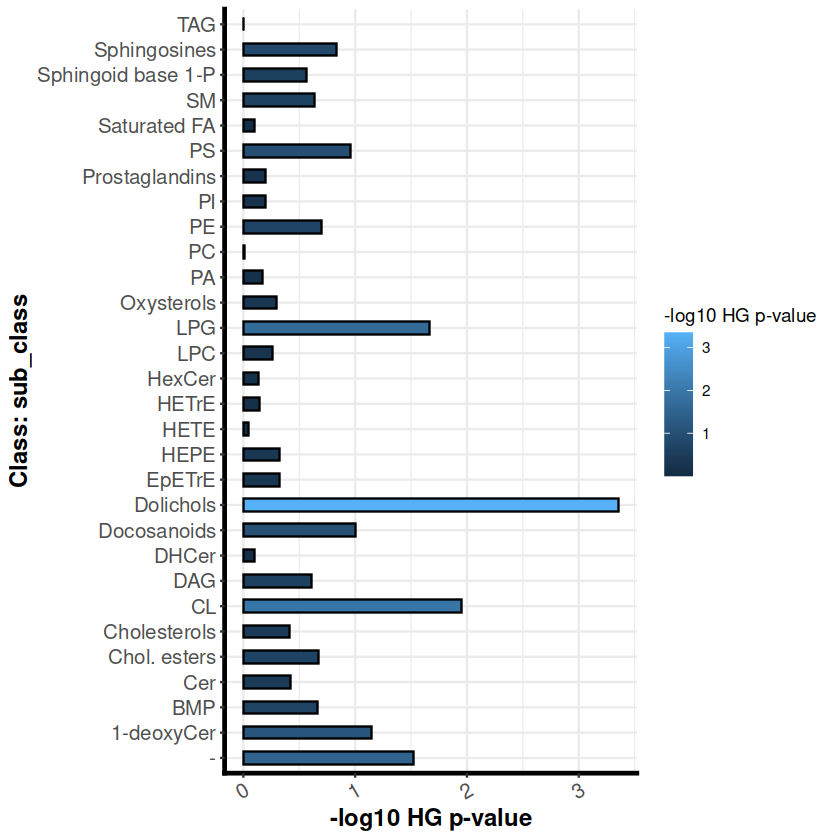

In [15]:
plot_met_enrichment(metenrichment, "sub_class","HG", no=1)
#plot_met_enrichment(metenrichment, "main_class","HG", no=1)
#plot_met_enrichment(metenrichment, "super_class","HG", no=1)


### Check the pathways with reactions of all the significant metabolites

In [16]:
met_path = met_pathways(df_metenrichment = metenrichment, 'hsa')
head(met_path)

,rxn,refmet_name,Exact mass,KEGG ID,Metabolite,Cirrhosis_mean,Normal_mean,Fold_change,log2Fold_change,t_value,⋯,metabolite_id,super_class,main_class,sub_class,formula,HG p-value,Rxn_name,PATHWAY,pathway_id,sps_path_id
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<named list>,<chr>,<chr>,<chr>,<chr>,<dbl>,<named list>,<chr>,<chr>,<chr>
1,R01003,Dolichol-20,1381.2782,C00381,Dolichol-20,18.54100,60.64903,3.271077,1.7097655,-7.141005,⋯,ME231044,Prenol Lipids,Polyprenols,Dolichols,C100H164O,0.0004447576,dolichyl....,N-Glycan biosynthesis,rn00510,hsa00510
2,R01003,Dolichol-20,1381.2782,C00381,Dolichol-20,18.54100,60.64903,3.271077,1.7097655,-7.141005,⋯,ME231044,Prenol Lipids,Polyprenols,Dolichols,C100H164O,0.0004447576,dolichyl....,Metabolic pathways,rn01100,hsa01100
3,R01018,Dolichol-20,1381.2782,C00381,Dolichol-20,18.54100,60.64903,3.271077,1.7097655,-7.141005,⋯,ME231044,Prenol Lipids,Polyprenols,Dolichols,C100H164O,0.0004447576,CTP:doli....,N-Glycan biosynthesis,rn00510,hsa00510
4,R01018,Dolichol-20,1381.2782,C00381,Dolichol-20,18.54100,60.64903,3.271077,1.7097655,-7.141005,⋯,ME231044,Prenol Lipids,Polyprenols,Dolichols,C100H164O,0.0004447576,CTP:doli....,Metabolic pathways,rn01100,hsa01100
5,R01310,PA 40:5,750.5200,C00416,PA(40:5),4.228153,7.135089,1.687519,0.7549038,-2.727375,⋯,ME231346,Glycerophospholipids,Glycerophosphates,PA,C43H75O8P,0.6760618214,phosphat....,Glycerophospholipid metabolism,rn00564,hsa00564
6,R01310,PA 40:5,750.5200,C00416,PA(40:5),4.228153,7.135089,1.687519,0.7549038,-2.727375,⋯,ME231346,Glycerophospholipids,Glycerophosphates,PA,C43H75O8P,0.6760618214,phosphat....,Metabolic pathways,rn01100,hsa01100


Find metabolites for which no pathways were registered in Kegg and/or no kegg id was found

In [17]:
setdiff(metenrichment$Metabolite,unique(met_path$Metabolite))

[1] "C16DH 1-deoxyCer" "C18DH 1-deoxyCer" "C20DH 1-deoxyCer" "C22DH 1-deoxyCer"
 [5] "C24DH 1-deoxyCer" "12-HEPE"          "12-HETE"          "14 HDoHE"        
 [9] "15-HETrE"         "16 HDoHE"         "4 HDoHE"          "BMP(40:7)"       
[13] "BMP(40:8)"        "Cholestanol"      "Dolichol-17"      "Dolichol-18"     
[17] "Dolichol-19"

### Get pathway enrichment sore.

Once we have the pathway information, we can calculate enrichment score of pathways. Again, here I have used hypergeometric (HG) score. For hypergeometric score, we need to know the total number of kegg compounds that are linked to kegg pathways.

N = total no. of compounds/metabolites linked to all kegg pathways (kegg_comp_path = TRUE) or the total number of metabolites detected in a study (kegg_comp_path = FALSE).

In the former case, this step might take long time, so I advice to run the script comp_linkedto_pathways() just the first time or after 6 months or so if desired to run the pipeline again. Save the result from comp_linkedto_pathways() and load it. Loading from saved file would save time for another analysis with another study. However the package takes care of loading. Save the data in the data folder.

L = No. of significant metabolites detected in a study

M = No. of significant metabolites detected in a metabolite class or pathway

k = Total no. of metabolites detected in a metabolite class/pathway

p-value = phyper(M-1, L, N-L, k, lower.tail=FALSE) # as in the actual R code # originally, it was wriiten as: phyper(M, L, N-L, K)

This function also utilizes korg dataset from pathview package.

In [18]:
load('../data/ls_path.RData')
load('../data/korg.RData')
#library(plyr); library(dplyr); source('../R/partial_join.R'); source('../R/path_enrichmentscore.R');
kegg_es = path_enrichmentscore(met_path,sig_metabolites_kegg_id=sig_metabolites_kegg_id,ls_path=ls_path,refmet_class=refmet_class,sps='hsa',padj='BH', kegg_comp_path=FALSE, debug = 0)

In [19]:
head(kegg_es)

,Pathway name,No. of sig mets in pathway,Total_no._of_comps_in_pathway,id,pathway_HG_p_value,Padjust
,<fct>,<int>,<int>,<chr>,<dbl>,<dbl>
1,alpha-Linolenic acid metabolism,2,44,C00157;C01226;C04672;C04780;C04785;C06427;C08491;C08492;C11512;C16300;C16308;C16309;C16310;C16311;C16316;C16317;C16318;C16319;C16320;C16321;C16322;C16323;C16324;C16325;C16326;C16327;C16328;C16330;C16331;C16332;C16334;C16335;C16336;C16338;C16339;C16341;C16342;C16343;C16344;C16345;C16346;C19757;C21923;C21924,9.939463e-01,1.000000e+00
2,Arachidonic acid metabolism,4,79,C00157;C00219;C00427;C00584;C00639;C00696;C00909;C01312;C02165;C02166;C02198;C03577;C04577;C04671;C04707;C04742;C04758;C04805;C04822;C04835;C04853;C05356;C05949;C05950;C05951;C05952;C05953;C05954;C05955;C05956;C05957;C05958;C05959;C05960;C05961;C05962;C05963;C05964;C05965;C05966;C06314;C06315;C06462;C13809;C14717;C14732;C14748;C14749;C14768;C14769;C14770;C14771;C14772;C14773;C14774;C14775;C14776;C14777;C14778;C14779;C14780;C14781;C14782;C14794;C14795;C14807;C14808;C14809;C14810;C14811;C14812;C14813;C14814;C14815;C14820;C14821;C14822;C14823;C14824,9.990825e-01,1.000000e+00
3,Biosynthesis of unsaturated fatty acids,1,74,C00154;C00219;C00249;C00412;C00510;C00712;C01203;C01530;C01595;C02041;C02050;C02249;C03035;C03242;C03595;C04088;C05764;C06425;C06426;C06427;C06428;C06429;C08281;C08316;C08320;C08323;C16160;C16161;C16162;C16163;C16164;C16165;C16166;C16167;C16168;C16169;C16170;C16171;C16172;C16173;C16179;C16180;C16513;C16522;C16525;C16526;C16527;C16528;C16529;C16530;C16531;C16532;C16533;C16645;C17279;C21072;C21932;C21934;C21935;C21937;C21939;C21941;C21943;C21945;C21947;C21949;C21951;C21953;C21959;C21961;C21963;C21965;C21967;C21981,9.999972e-01,1.000000e+00
4,Glycerolipid metabolism,20,38,C00029;C00040;C00093;C00103;C00111;C00116;C00162;C00173;C00184;C00197;C00258;C00416;C00422;C00577;C00631;C00641;C00681;C00969;C01885;C02133;C02457;C03692;C04046;C04315;C04872;C05401;C06037;C06038;C06040;C06041;C06042;C06364;C06365;C11521;C13508;C20897;C20898;C20991,1.037033e-08,5.530845e-08
5,Glycerophospholipid metabolism,28,56,C00040;C00065;C00084;C00093;C00111;C00114;C00157;C00189;C00269;C00307;C00344;C00346;C00350;C00416;C00513;C00570;C00588;C00623;C00641;C00670;C00681;C01194;C01210;C01233;C01241;C01996;C02737;C03372;C03819;C03872;C03892;C03974;C04230;C04233;C04308;C04438;C04590;C04638;C05973;C05974;C05976;C05980;C06771;C06772;C13482;C18059;C18125;C18126;C18129;C18168;C18169;C20466;C20518;C22340;C22341;C22342,2.023519e-11,1.618815e-10
6,"Glycine, serine and threonine metabolism",4,50,C00011;C00014;C00022;C00037;C00048;C00049;C00065;C00078;C00097;C00101;C00109;C00114;C00143;C00168;C00188;C00197;C00213;C00258;C00263;C00300;C00430;C00441;C00546;C00576;C00581;C00631;C00719;C00740;C00986;C01005;C01026;C01102;C01242;C01888;C02051;C02291;C02737;C02972;C03082;C03194;C03232;C03283;C03508;C05519;C06231;C06442;C16432;C19929;C23135;C23136,9.569863e-01,1.000000e+00


### Plot pathway network
Only plotting significant pathways (pathway with p-value significance).

The pathway network is such that it shows metabolites that are connected to different pathways and same metabolite in different pathway. Color of nodes of metabolites are according to the fold change of metabolites (low expression in green and high in red) and size of pathway nodes (square nodes) are according to the number of branches (meaning no of metabolites). All metabolite are written in blue

Warning message:
“ggrepel: 11 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


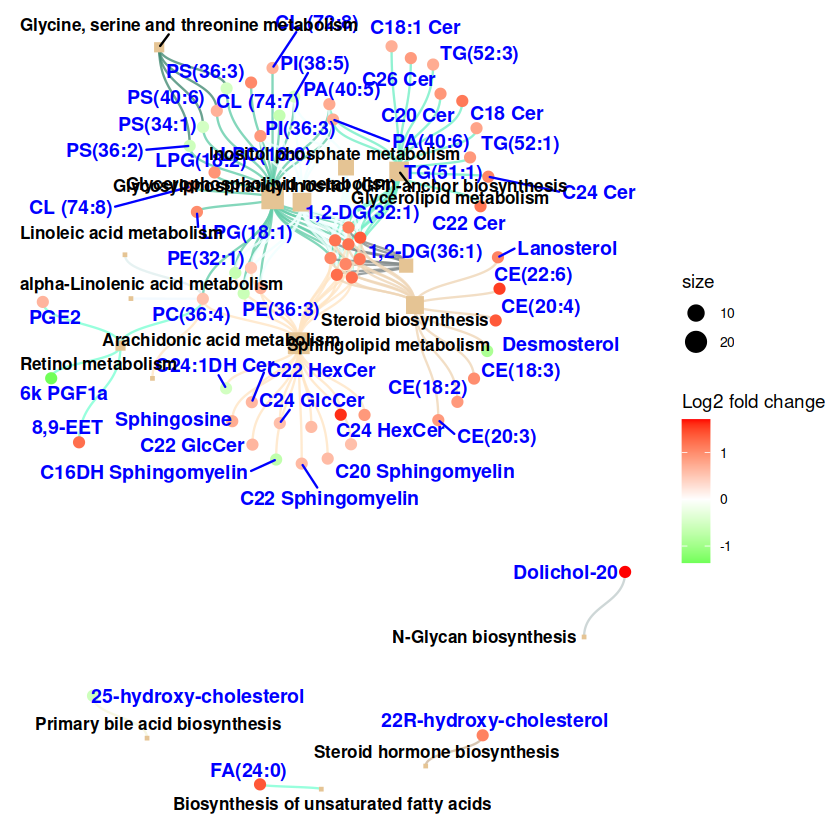

In [20]:
plot_pathway_networks (met_path,kegg_es, TRUE)

### Heatmap

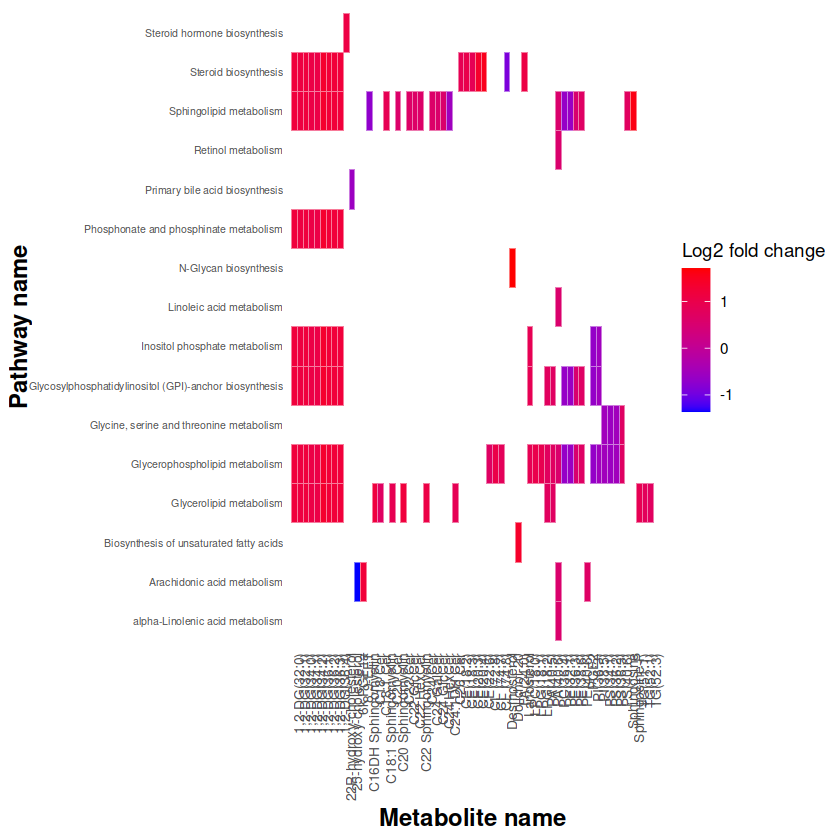

In [21]:
plot_heatmap(met_path, shorten_name=TRUE,refmet_name=FALSE, xaxis=8, yaxis=6)

### Dotplot

Warning message:
“Use of `significant_pathways[["pathway_HG_p_value"]]` is discouraged.
ℹ Use `.data[["pathway_HG_p_value"]]` instead.”


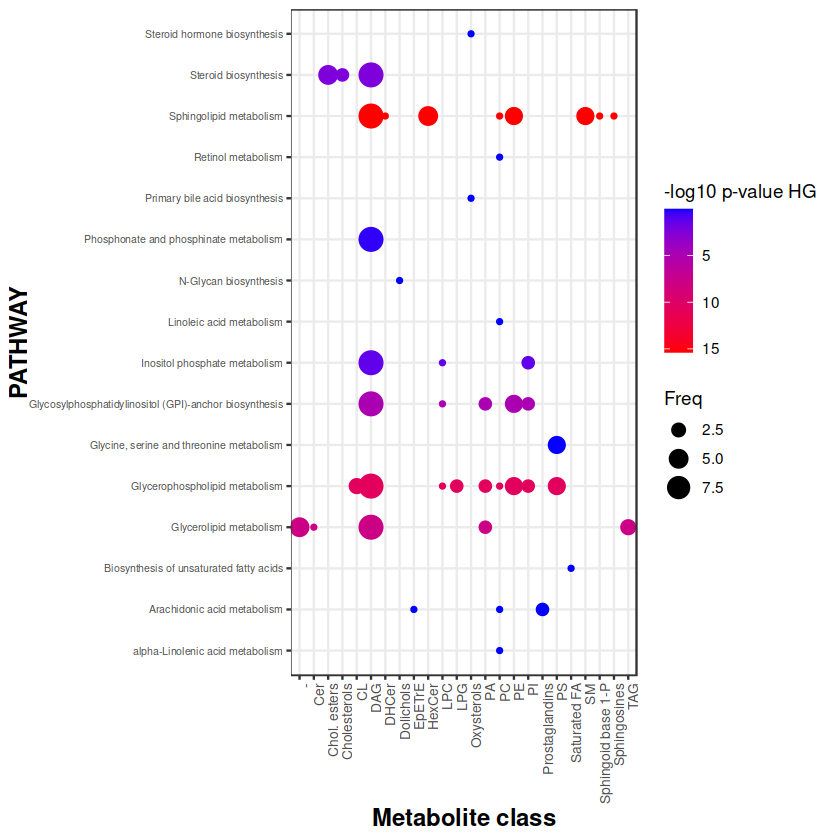

In [22]:

dotplot_met_class_path (met_path, kegg_es,"sub_class",xaxis=8,yaxis=6)

### Get the gene and enzyme info

Here we get the information of genes involved in enriched pathways for specified organism

In [23]:
met_gene_info = enzyme_gene_info (metenrichment, "hsa","sub_class")
head(met_gene_info)

,orthology_id,ORTHOLOGY,gene_id,gene_name,ORGANISM,PATHWAY,DBLINKS,MOTIF,rxn,Metabolite,KEGG ID,sub_class,Rxn_name,RCLASS,EQUATION,EQUATION_more,ENZYME
,<chr>,<chr>,<named list>,<named list>,<named list>,<named list>,<named list>,<named list>,<chr>,<chr>,<chr>,<chr>,<named list>,<named list>,<named list>,<named list>,<named list>
1,K00069,15-hydroxyprostaglandin dehydrogenase (NAD) [EC:1.1.1.141],3248,(RefSeq)....,Homo sap....,Arachido....,NCBI-Gen....,Pfam: ad....,R02580,PGE2,C00584,Prostaglandins,"(5Z,13E)....",RC00001 ....,C00584 +....,Prostagl....,1.1.1.141
2,K00079,carbonyl reductase 1 [EC:1.1.1.184 1.1.1.189 1.1.1.197],873,(RefSeq)....,Homo sap....,Arachido....,NCBI-Gen....,Pfam: ad....,R02581,PGE2,C00584,Prostaglandins,"(5Z,13E)....",RC00001 ....,C00639 +....,Prostagl....,1.1.1.18....
3,K00084,carbonyl reductase 3 [EC:1.1.1.184],874,(RefSeq)....,Homo sap....,Arachido....,NCBI-Gen....,Pfam: ad....,R02581,PGE2,C00584,Prostaglandins,"(5Z,13E)....",RC00001 ....,C00639 +....,Prostagl....,1.1.1.18....
4,K00498,cholesterol monooxygenase (side-chain-cleaving) [EC:1.14.15.6],1583,(RefSeq)....,Homo sap....,Steroid ....,NCBI-Gen....,Pfam: p4....,R04855,22R-hydroxy-cholesterol,C05502,Oxysterols,22beta-h....,RC00706 ....,C05502 +....,22(R)-Hy....,1.14.15.6
5,K00498,cholesterol monooxygenase (side-chain-cleaving) [EC:1.14.15.6],1583,(RefSeq)....,Homo sap....,Steroid ....,NCBI-Gen....,Pfam: p4....,R02723,22R-hydroxy-cholesterol,C05502,Oxysterols,,RC00773 ....,C00187 +....,Choleste....,1.14.15.6
6,K00551,phosphatidylethanolamine/phosphatidyl-N-methylethanolamine N-methyltransferase [EC:2.1.1.17 2.1.1.71],10400,(RefSeq)....,Homo sap....,Glycerop....,NCBI-Gen....,Pfam: PE....,R02056,PE(38:6),C00350,PE,S-adenos....,RC00003 ....,C00019 +....,S-Adenos....,2.1.1.17


#### Get the information if metabolite is a reactant or substrate

In [24]:
rclass_info = react_substrate(met_gene_info)
head(rclass_info)

,orthology_id,ORTHOLOGY,gene_id,gene_name,ORGANISM,PATHWAY,DBLINKS,MOTIF,rxn,Metabolite,KEGG ID,sub_class,Rxn_name,RCLASS,EQUATION,EQUATION_more,ENZYME,reactant_product
,<chr>,<chr>,<named list>,<named list>,<named list>,<named list>,<named list>,<named list>,<chr>,<chr>,<chr>,<chr>,<named list>,<named list>,<named list>,<named list>,<named list>,<chr>
1,K00069,15-hydroxyprostaglandin dehydrogenase (NAD) [EC:1.1.1.141],3248,(RefSeq)....,Homo sap....,Arachido....,NCBI-Gen....,Pfam: ad....,R02580,PGE2,C00584,Prostaglandins,"(5Z,13E)....",RC00001 ....,C00584 +....,Prostagl....,1.1.1.141,Substrate
2,K00079,carbonyl reductase 1 [EC:1.1.1.184 1.1.1.189 1.1.1.197],873,(RefSeq)....,Homo sap....,Arachido....,NCBI-Gen....,Pfam: ad....,R02581,PGE2,C00584,Prostaglandins,"(5Z,13E)....",RC00001 ....,C00639 +....,Prostagl....,1.1.1.18....,Product
3,K00084,carbonyl reductase 3 [EC:1.1.1.184],874,(RefSeq)....,Homo sap....,Arachido....,NCBI-Gen....,Pfam: ad....,R02581,PGE2,C00584,Prostaglandins,"(5Z,13E)....",RC00001 ....,C00639 +....,Prostagl....,1.1.1.18....,Product
4,K00498,cholesterol monooxygenase (side-chain-cleaving) [EC:1.14.15.6],1583,(RefSeq)....,Homo sap....,Steroid ....,NCBI-Gen....,Pfam: p4....,R04855,22R-hydroxy-cholesterol,C05502,Oxysterols,22beta-h....,RC00706 ....,C05502 +....,22(R)-Hy....,1.14.15.6,Substrate
5,K00498,cholesterol monooxygenase (side-chain-cleaving) [EC:1.14.15.6],1583,(RefSeq)....,Homo sap....,Steroid ....,NCBI-Gen....,Pfam: p4....,R02723,22R-hydroxy-cholesterol,C05502,Oxysterols,,RC00773 ....,C00187 +....,Choleste....,1.14.15.6,Product
6,K00551,phosphatidylethanolamine/phosphatidyl-N-methylethanolamine N-methyltransferase [EC:2.1.1.17 2.1.1.71],10400,(RefSeq)....,Homo sap....,Glycerop....,NCBI-Gen....,Pfam: PE....,R02056,PE(38:6),C00350,PE,S-adenos....,RC00003 ....,C00019 +....,S-Adenos....,2.1.1.17,Substrate


#### Get gene info in short form

In [25]:
met_gene_info2=data.table::data.table(rclass_info)[,lapply(.SD, function(x) toString(unique(x))), by = 'Metabolite']